# Crypto returns PCA — linear algebra, made of real prices

A teaching notebook: take everything from a month of linear-algebra revision
— covariance matrices, eigendecomposition, SVD, orthogonal projection,
quadratic forms — and watch it act on real crypto returns.

**Data:** daily (`1Dutc`) candles pulled live from the OKX public REST API.
No auth, no tick decode — for a *returns* PCA, closes are all we need. OKX is
chosen over our HL tape here precisely because it carries **BTC + the majors**
(the HL archive excludes BTC), and it's already bar-aggregated.

**The LA → quant dictionary this notebook walks through:**

| step | linear algebra | what it means here |
|---|---|---|
| 4 | covariance matrix `Σ` (symmetric, PSD) | the central risk object |
| 5 | eigendecomposition `Σ = VΛVᵀ` | the principal factors |
| 6 | explained variance `λᵢ/Σλ` | how rank-1 crypto really is |
| 7 | eigenvectors as loadings | PC1 = market, PC2 = majors-vs-alts |
| 8 | SVD of `R` ≡ eig of `RᵀR` | the identity, proven on live data |
| 9 | Marchenko–Pastur | signal eigenvalues vs the noise bulk |
| 10 | orthogonal projection `R·V` | factor return series + residual |

Single venue, single clock → no cross-exchange basis/skew artifacts. Clean.


## 0. Imports

In [1]:
%matplotlib inline
import time
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. Pull daily candles from OKX REST

`history-candles` returns up to 100 bars per call, **newest-first**, as
`[ts, o, h, l, c, vol, volCcy, volCcyQuote, confirm]`. We paginate backwards
with the `after` param (older than the given ms-timestamp) and keep only
**confirmed** (closed) bars — `confirm == "1"`. `bar=1Dutc` cuts every
instrument on the same UTC midnight, so the panel is mutually aligned.


In [2]:
OKX = "https://www.okx.com/api/v5/market/history-candles"

# Liquid USDT-margined linear perps. BTC first so it anchors the basket
# (the asset our HL tape is missing). Edit this list freely.
UNIVERSE = [
    "BTC", "ETH", "SOL", "BNB", "XRP", "DOGE", "ADA", "AVAX",
    "LINK", "LTC", "DOT", "BCH", "NEAR", "APT", "ARB", "SUI",
    "TON", "TRX", "FIL", "OP",
]
INST = [f"{b}-USDT-SWAP" for b in UNIVERSE]

N_BARS = 540   # ~18 months of daily bars

def fetch_daily(inst_id, n_bars=N_BARS, bar="1Dutc"):
    """Paginate history-candles backwards; return a tz-aware close Series."""
    rows, after = [], None
    while len(rows) < n_bars:
        params = {"instId": inst_id, "bar": bar, "limit": 100}
        if after is not None:
            params["after"] = after
        r = requests.get(OKX, params=params, timeout=20)
        r.raise_for_status()
        batch = r.json().get("data", [])
        if not batch:
            break
        rows.extend(batch)
        after = batch[-1][0]          # oldest ts in this batch → page older
        time.sleep(0.15)              # be polite to the rate limiter
    if not rows:
        return pd.Series(dtype=float, name=inst_id)
    df = pd.DataFrame(rows, columns=[
        "ts", "o", "h", "l", "c", "vol", "volCcy", "volCcyQuote", "confirm"])
    df = df[df.confirm == "1"]        # closed bars only
    ts = pd.to_datetime(df.ts.astype("int64"), unit="ms", utc=True)
    close = pd.Series(df.c.astype(float).values, index=ts, name=inst_id)
    return close[~close.index.duplicated()].sort_index()

closes = {}
for inst in INST:
    s = fetch_daily(inst)
    closes[inst.split("-")[0]] = s
    print(f"{inst:18s} {len(s):4d} bars  "
          f"{s.index.min().date()} → {s.index.max().date()}")

BTC-USDT-SWAP       599 bars  2024-10-17 → 2026-06-07


ETH-USDT-SWAP       599 bars  2024-10-17 → 2026-06-07


SOL-USDT-SWAP       599 bars  2024-10-17 → 2026-06-07


BNB-USDT-SWAP       599 bars  2024-10-17 → 2026-06-07


XRP-USDT-SWAP       599 bars  2024-10-17 → 2026-06-07


...

SUI-USDT-SWAP       599 bars  2024-10-17 → 2026-06-07


TON-USDT-SWAP       599 bars  2024-10-17 → 2026-06-07


TRX-USDT-SWAP       599 bars  2024-10-17 → 2026-06-07


FIL-USDT-SWAP       599 bars  2024-10-17 → 2026-06-07


OP-USDT-SWAP        599 bars  2024-10-17 → 2026-06-07


## 2. Build the aligned close matrix

Concatenate into a `T × N` frame on the shared UTC-midnight index. Instruments
listed mid-window have leading NaNs; we drop dates where *any* name is missing
so every column spans the same calendar — a clean rectangular matrix, which is
what the covariance estimator assumes.


In [3]:
prices = pd.DataFrame(closes).sort_index()
print("raw panel:", prices.shape)

# Keep the largest fully-populated rectangular block.
prices = prices.dropna(how="any")
print("aligned   :", prices.shape, "  cols:", list(prices.columns))
print(prices.tail(3))

raw panel: (599, 20)
aligned   : (599, 20)   cols: ['BTC', 'ETH', 'SOL', 'BNB', 'XRP', 'DOGE', 'ADA', 'AVAX', 'LINK', 'LTC', 'DOT', 'BCH', 'NEAR', 'APT', 'ARB', 'SUI', 'TON', 'TRX', 'FIL', 'OP']
                               BTC      ETH    SOL    BNB    XRP     DOGE  \
ts                                                                          
2026-06-05 00:00:00+00:00  61025.2  1582.49  63.60  571.9  1.097  0.08143   
2026-06-06 00:00:00+00:00  60849.2  1568.62  62.15  574.1  1.093  0.08185   
2026-06-07 00:00:00+00:00  63308.0  1689.63  66.46  604.0  1.155  0.08622   

                              ADA   AVAX   LINK    LTC    DOT    BCH   NEAR  \
ts                                                                            
2026-06-05 00:00:00+00:00  0.1565  6.721  7.360  43.29  0.944  209.7  1.967   
2026-06-06 00:00:00+00:00  0.1571  6.658  7.391  41.35  0.941  217.1  1.857   
2026-06-07 00:00:00+00:00  0.1652  6.811  7.912  42.79  0.971  230.1  2.058   

                       

## 3. Log returns → the data matrix `R`

`R[t, i] = ln(P[t,i] / P[t-1,i])`. Then **demean each column** — PCA explains
variance *about the mean*, so a non-zero mean would leak into the factors.
`R` is our `T × N` data matrix; every row is one day's cross-section.


In [4]:
R = np.log(prices).diff().dropna()
T, Nv = R.shape
print(f"R is {T} × {Nv}   (T={T} observations, N={Nv} instruments)")

Rc = R - R.mean(axis=0)          # column-demeaned
print("column means after centering (≈0):", np.allclose(Rc.mean(axis=0), 0))

R is 598 × 20   (T=598 observations, N=20 instruments)
column means after centering (≈0): True


## 4. The covariance matrix `Σ = RᵀR / (T−1)`

The central object. **Symmetric** by construction, and **positive
semi-definite** because for any weight vector `w`, the quadratic form
`wᵀΣw = Var(R·w) ≥ 0` — the variance of a portfolio can't be negative.
That single fact is *why* its eigenvalues are all ≥ 0 and its eigenvectors
are orthogonal. Look at the matrix: this is your revision, made of prices.


symmetric?  True
wᵀΣw for 5 random w: [0.028  0.0088 0.0792 0.0786 0.0159]


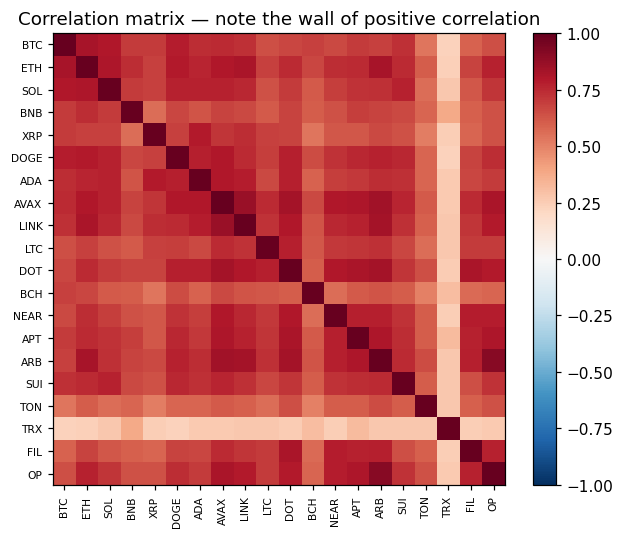

In [5]:
X = Rc.values
Sigma = (X.T @ X) / (T - 1)      # N×N covariance

print("symmetric? ", np.allclose(Sigma, Sigma.T))
# PSD check via a few random portfolios: wᵀΣw ≥ 0
ws = np.random.default_rng(0).standard_normal((5, Nv))
print("wᵀΣw for 5 random w:", np.round([w @ Sigma @ w for w in ws], 8))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(np.corrcoef(X.T), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(Nv)); ax.set_xticklabels(R.columns, rotation=90, fontsize=7)
ax.set_yticks(range(Nv)); ax.set_yticklabels(R.columns, fontsize=7)
ax.set_title("Correlation matrix — note the wall of positive correlation")
fig.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()

## 5. Eigendecomposition `Σ = V Λ Vᵀ`

`np.linalg.eigh` is the right call: it's specialised for symmetric matrices,
returns **real** eigenvalues and **orthonormal** eigenvectors, and is more
stable than the general `eig`. It returns ascending eigenvalues, so we flip to
descending — PC1 first.


In [6]:
lam, V = np.linalg.eigh(Sigma)   # ascending
order = np.argsort(lam)[::-1]
lam, V = lam[order], V[:, order]

print("eigenvalues (descending):")
print(lam)
print("\northonormal? VᵀV ≈ I:", np.allclose(V.T @ V, np.eye(Nv), atol=1e-10))
print("reconstructs Σ? VΛVᵀ ≈ Σ:",
      np.allclose(V @ np.diag(lam) @ V.T, Sigma))

eigenvalues (descending):
[0.03   0.0018 0.0013 0.0011 0.0009 0.0009 0.0008 0.0007 0.0006 0.0006
 0.0005 0.0005 0.0004 0.0004 0.0003 0.0003 0.0003 0.0002 0.0002 0.0001]

orthonormal? VᵀV ≈ I: True
reconstructs Σ? VΛVᵀ ≈ Σ: True


## 6. Explained variance — how rank-1 is crypto, really?

Each `λᵢ / Σλ` is the share of total cross-sectional variance carried by
factor `i`. Crypto is famously close to a one-factor system — expect PC1 to
swallow a large majority.


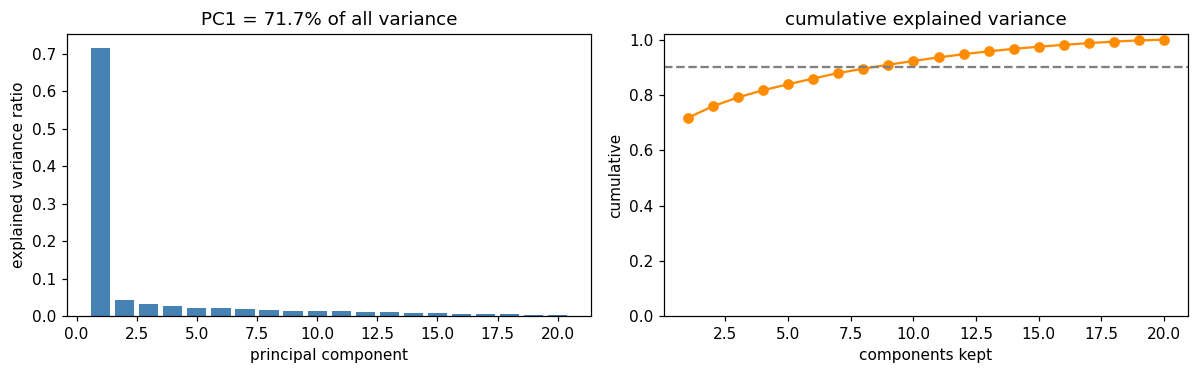

PC1..PC5 explained: [0.7171 0.0422 0.0319 0.026  0.0216]


In [7]:
evr = lam / lam.sum()
cum = np.cumsum(evr)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.5))
a1.bar(range(1, Nv + 1), evr, color="steelblue")
a1.set_xlabel("principal component"); a1.set_ylabel("explained variance ratio")
a1.set_title(f"PC1 = {evr[0]*100:.1f}% of all variance")
a2.plot(range(1, Nv + 1), cum, "-o", color="darkorange")
a2.axhline(0.9, ls="--", c="grey"); a2.set_ylim(0, 1.02)
a2.set_xlabel("components kept"); a2.set_ylabel("cumulative")
a2.set_title("cumulative explained variance")
plt.tight_layout()
plt.show()
print("PC1..PC5 explained:", np.round(evr[:5], 4))

## 7. Reading the eigenvectors — what *are* the factors?

The eigenvectors are loadings: how much each instrument moves with that factor.

- **PC1** should be all-same-sign — the **market factor** ("everything moves
  together"). Note BTC/ETH carry the biggest loadings.
- **PC2** typically flips sign across the basket — a rotation, often
  **majors vs. alts** or large-cap vs. small-cap.


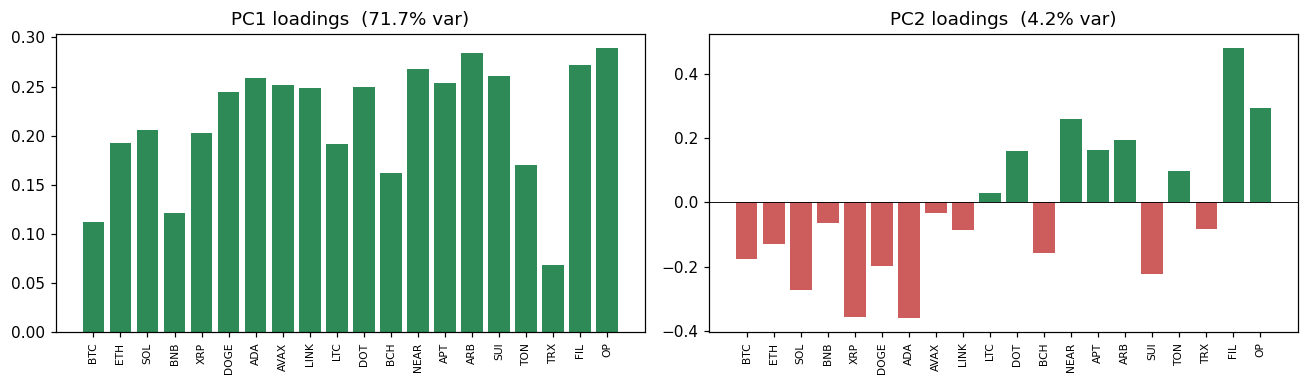

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for k, ax in zip([0, 1], axes):
    v = V[:, k]
    # sign convention: make the largest-magnitude loading positive
    v = v * np.sign(v[np.argmax(np.abs(v))])
    colors = ["seagreen" if x >= 0 else "indianred" for x in v]
    ax.bar(R.columns, v, color=colors)
    ax.axhline(0, c="k", lw=0.6)
    ax.set_title(f"PC{k+1} loadings  ({evr[k]*100:.1f}% var)")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

## 8. The SVD identity — same factors, different door

From the revision: the SVD `R = U S Wᵀ` and the eigendecomposition of
`Σ ∝ RᵀR` are the *same thing*. The right-singular vectors `W` are the
eigenvectors `V`, and the singular values satisfy `λᵢ = sᵢ² / (T−1)`. Quants
prefer SVD in practice — it never forms `RᵀR` explicitly, so it's numerically
stabler. Let's prove the identity holds on this data.


In [9]:
U, S, Wt = np.linalg.svd(X, full_matrices=False)
lam_svd = (S ** 2) / (T - 1)

print("eigenvalues from eigh:", np.round(lam[:5], 6))
print("from SVD (s²/(T-1))  :", np.round(lam_svd[:5], 6))
print("\nmatch:", np.allclose(lam, lam_svd))

# eigenvectors equal up to a sign flip per component
v_eig = V[:, 0] * np.sign(V[np.argmax(np.abs(V[:, 0])), 0])
v_svd = Wt[0] * np.sign(Wt[0][np.argmax(np.abs(Wt[0]))])
print("PC1 vector matches across both methods:", np.allclose(v_eig, v_svd))

eigenvalues from eigh: [0.03   0.0018 0.0013 0.0011 0.0009]
from SVD (s²/(T-1))  : [0.03   0.0018 0.0013 0.0011 0.0009]

match: True
PC1 vector matches across both methods: True


## 9. Marchenko–Pastur — which eigenvalues are real?

Where random-matrix theory meets your covariance revision. If returns were
**pure noise**, the eigenvalues of the *correlation* matrix would fall inside
the Marchenko–Pastur band

$$\lambda_\pm = \left(1 \pm \sqrt{q}\,\right)^2, \qquad q = N/T.$$

Anything **above** `λ₊` is statistically real structure; the bulk **inside**
the band is indistinguishable from noise. Watch PC1 (and maybe PC2) stick out
while the rest sit in the noise sea — that's the rigorous version of "how many
factors are there."


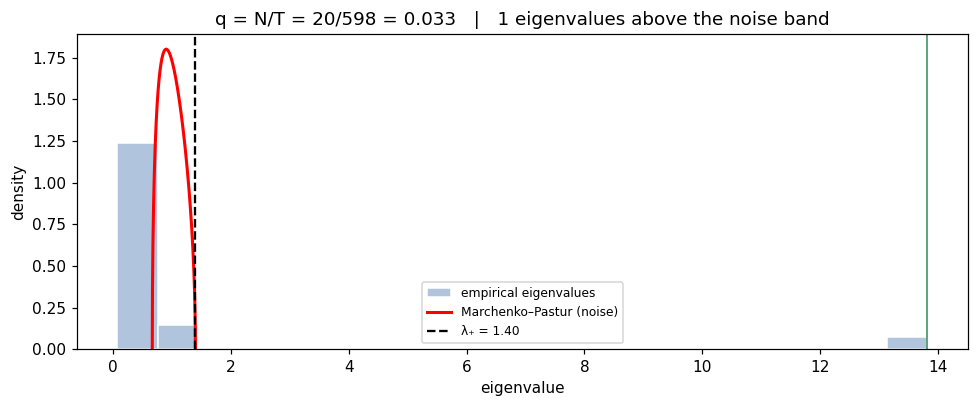

eigenvalues above λ₊ (real factors): [13.82]


In [10]:
# MP applies to the correlation matrix (unit-variance assumption).
Z = (X - X.mean(0)) / X.std(0, ddof=1)
C = (Z.T @ Z) / (T - 1)
eig_c = np.sort(np.linalg.eigvalsh(C))[::-1]

q = Nv / T
lam_plus  = (1 + np.sqrt(q)) ** 2
lam_minus = (1 - np.sqrt(q)) ** 2

# MP density for the overlay
xs = np.linspace(max(lam_minus, 1e-6), lam_plus, 400)
mp = np.sqrt(np.clip((lam_plus - xs) * (xs - lam_minus), 0, None)) / (2 * np.pi * q * xs)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(eig_c, bins=Nv, density=True, color="lightsteelblue",
        edgecolor="white", label="empirical eigenvalues")
ax.plot(xs, mp, "r-", lw=2, label="Marchenko–Pastur (noise)")
ax.axvline(lam_plus, c="k", ls="--", label=f"λ₊ = {lam_plus:.2f}")
for e in eig_c[eig_c > lam_plus]:
    ax.axvline(e, c="seagreen", lw=1)
ax.set_xlabel("eigenvalue"); ax.set_ylabel("density")
ax.set_title(f"q = N/T = {Nv}/{T} = {q:.3f}   |   "
             f"{int((eig_c > lam_plus).sum())} eigenvalues above the noise band")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print("eigenvalues above λ₊ (real factors):",
      np.round(eig_c[eig_c > lam_plus], 3))

## 10. Projection — factor return series & the residual

The eigenvectors are an orthonormal basis. **Projecting** returns onto the top
`k` of them, `F = R·V[:, :k]`, gives the *factor return time series* — PC1's
series is essentially "the crypto market's daily return." Reconstructing from
`k` factors and subtracting gives the **residual** (idiosyncratic) return — the
part of each coin not explained by the market. That residual is exactly what a
stat-arb / pairs signal would try to trade, and what you'd hedge to neutralise.


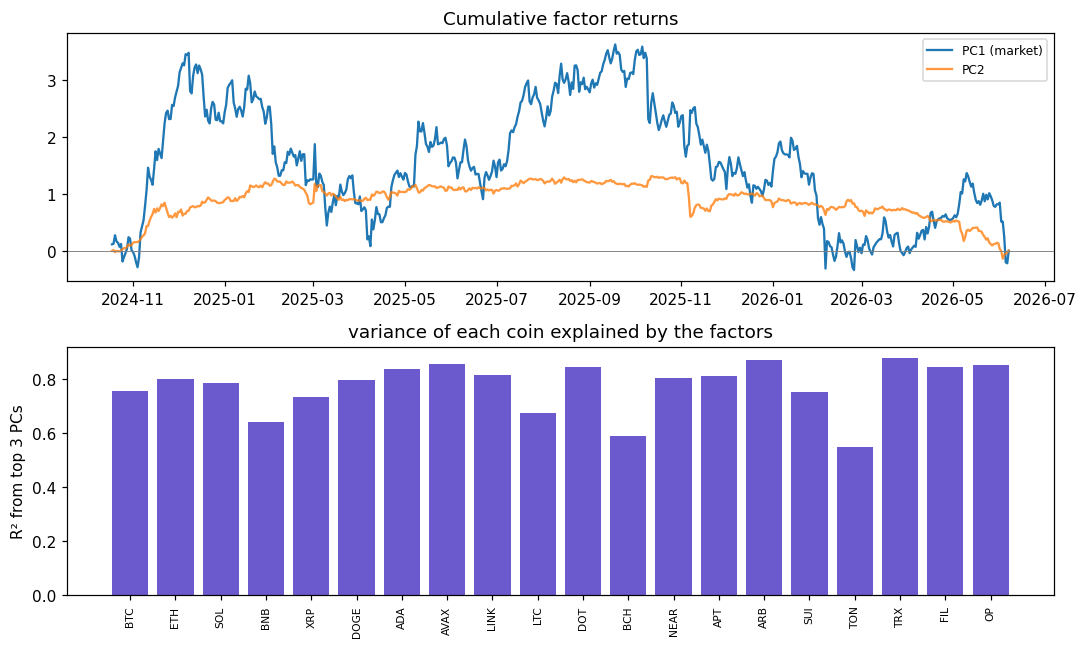

top-3 factors explain 79.1% of total variance


In [11]:
k = 3
F = X @ V[:, :k]                       # T × k factor returns
recon = F @ V[:, :k].T                 # back to instrument space
resid = X - recon                      # idiosyncratic part

fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6))   # distinct x-axes (time vs category)
a1.plot(R.index, np.cumsum(F[:, 0]), label="PC1 (market)")
a1.plot(R.index, np.cumsum(F[:, 1]), label="PC2", alpha=0.8)
a1.set_title("Cumulative factor returns"); a1.legend(fontsize=8)
a1.axhline(0, c="grey", lw=0.6)

var_explained = 1 - resid.var(0) / X.var(0)
a2.bar(R.columns, var_explained, color="slateblue")
a2.set_ylabel(f"R² from top {k} PCs"); a2.set_title("variance of each coin explained by the factors")
a2.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
plt.show()
print(f"top-{k} factors explain {cum[k-1]*100:.1f}% of total variance")

## Where this goes next

You now have, on real data: a covariance matrix, its eigendecomposition, the
SVD identity, an MP noise test, and factor/residual series. Natural follow-ons,
each tied to a part of the system:

- **Risk / hedging** — the PC1 loadings *are* the market-beta hedge for AS
  inventory: hedge the factor, not each leg.
- **Universe selection** (`bpt-universe`) — cluster instruments on their
  loadings so you don't quote five names that are one bet.
- **Stability** — re-run `Σ` on rolling windows; watch how PC1 explained-var
  and loadings drift. Crypto's factor structure is *not* stationary.
- **Vol-surface PCA** — the higher-edge cousin for the Deribit options MM:
  level/slope/curvature factors on the smile.
